In [1]:
import kagglehub

# Descargar PlantVillage
print("Descargando dataset (690 MB)... esto puede tardar varios minutos.")
path = kagglehub.dataset_download("emmarex/plantdisease")
print(f"Dataset descargado en: {path}")

c:\ProgramData\miniconda3\envs\pdi26\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Descargando dataset (690 MB)... esto puede tardar varios minutos.


100%|██████████| 658M/658M [07:14<00:00, 1.59MB/s] 

Extracting files...


Dataset descargado en: C:\Users\victus\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1


In [2]:
import sys
print(f"Python activo: {sys.version}")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shutil
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# Rangos HSV para deteccion de cada condicion foliar
# OpenCV usa: H=0-180, S=0-255, V=0-255
# ============================================================
HSV_HOJA = {                          # Verde — area de la hoja sana
    'lower': np.array([25, 40,  40]),
    'upper': np.array([85, 255, 255])
}
HSV_NECROSIS = {                      # Cafe oscuro — manchas necroticas
    'lower': np.array([ 5,  60,  20]),
    'upper': np.array([20, 200, 100])
}
HSV_CLOROSIS = {                      # Amarillo — clorosis por nutrientes
    'lower': np.array([20,  80, 100]),
    'upper': np.array([35, 255, 255])
}
HSV_HONGO = {                         # Blanco/gris — moho o hongo
    'lower': np.array([  0,  0, 160]),
    'upper': np.array([180, 60, 255])
}

# Etiquetas y colores BGR para el HUD de video
CLASES = {0: 'Sana', 1: 'Necrosis', 2: 'Clorosis', 3: 'Hongo', 4: 'Deshidratada'}
COLORES = {
    0: (  0, 255,   0),
    1: (  0,  80, 180),
    2: (  0, 220, 220),
    3: (200, 200, 200),
    4: (255, 130,   0),
}

MODEL_PATH = 'modelo_plantas.pkl'

print("Librerias importadas correctamente.")
print(f"OpenCV version: {cv2.__version__}")
print("Rangos HSV y constantes cargados.")


Python activo: 3.14.2 | packaged by Anaconda, Inc. | (main, Dec 19 2025, 11:44:48) [MSC v.1929 64 bit (AMD64)]
Librerias importadas correctamente.
OpenCV version: 4.12.0
Rangos HSV y constantes cargados.


Camara 0 abierta. Resolucion: 640x480  FPS: 30


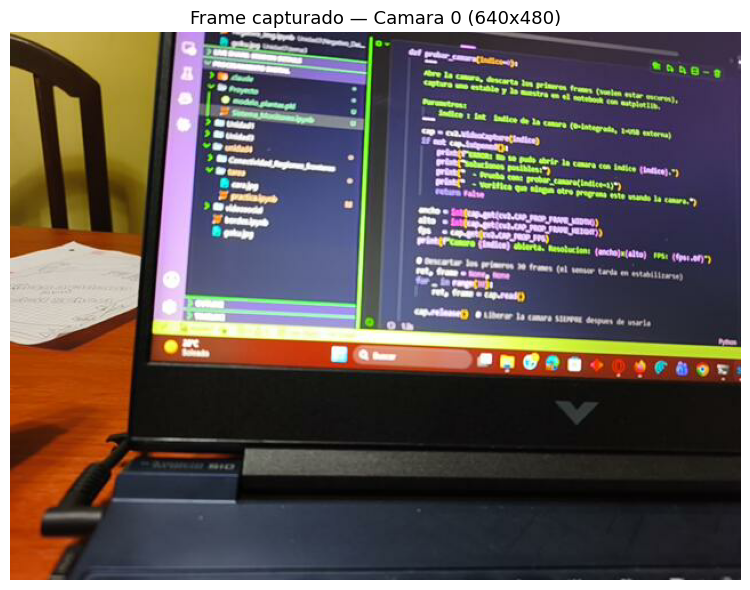

Camara verificada exitosamente. Lista para el sistema.


True

In [3]:
def probar_camara(indice=0):
    """
    Abre la camara, descarta los primeros frames (suelen estar oscuros),
    captura uno estable y lo muestra en el notebook con matplotlib.

    Parametros:
        indice : int  indice de la camara (0=integrada, 1=USB externa)
    """
    cap = cv2.VideoCapture(indice)
    if not cap.isOpened():
        print(f"ERROR: No se pudo abrir la camara con indice {indice}.")
        print("Soluciones posibles:")
        print("  - Prueba con: probar_camara(indice=1)")
        print("  - Verifica que ningun otro programa este usando la camara.")
        return False

    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    print(f"Camara {indice} abierta. Resolucion: {ancho}x{alto}  FPS: {fps:.0f}")

    # Descartar los primeros 30 frames (el sensor tarda en estabilizarse)
    ret, frame = None, None
    for _ in range(30):
        ret, frame = cap.read()

    cap.release()  # Liberar la camara SIEMPRE despues de usarla

    if not ret or frame is None:
        print("ERROR: No se pudo leer ningun frame de la camara.")
        return False

    # Convertir BGR -> RGB para mostrar con matplotlib
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(9, 6))
    plt.imshow(frame_rgb)
    plt.title(f"Frame capturado — Camara {indice} ({ancho}x{alto})", fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print("Camara verificada exitosamente. Lista para el sistema.")
    return True


# Prueba la camara integrada (indice 0)
# Si no funciona, ejecuta: probar_camara(indice=1)
probar_camara(indice=0)


In [4]:
RUTA_PLANTVILLAGE = r"C:\Users\victus\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage"
RUTA_DATASET_PROCESADO = "dataset_procesado"
MAX_POR_CLASE = 500

# Mapeo explicito: carpeta original → (indice_clase, nombre_clase)
# Spider mites → Deshidratada (marchitez por estres hidrico visible)
MAPA_CARPETA_CLASE = {
    'Pepper__bell___healthy':                       (0, 'sana'),
    'Potato___healthy':                             (0, 'sana'),
    'Tomato_healthy':                               (0, 'sana'),
    'Pepper__bell___Bacterial_spot':                (1, 'necrosis'),
    'Potato___Early_blight':                        (1, 'necrosis'),
    'Potato___Late_blight':                         (1, 'necrosis'),
    'Tomato_Bacterial_spot':                        (1, 'necrosis'),
    'Tomato_Early_blight':                          (1, 'necrosis'),
    'Tomato_Late_blight':                           (1, 'necrosis'),
    'Tomato_Septoria_leaf_spot':                    (1, 'necrosis'),
    'Tomato__Target_Spot':                          (1, 'necrosis'),
    'Tomato__Tomato_YellowLeaf__Curl_Virus':        (2, 'clorosis'),
    'Tomato__Tomato_mosaic_virus':                  (2, 'clorosis'),
    'Tomato_Leaf_Mold':                             (3, 'hongo'),
    'Tomato_Spider_mites_Two_spotted_spider_mite':  (4, 'deshidratada'),
}


def organizar_dataset(ruta_origen=RUTA_PLANTVILLAGE,
                      ruta_destino=RUTA_DATASET_PROCESADO,
                      max_por_clase=MAX_POR_CLASE,
                      seed=42):
    """
    Copia (no mueve) imagenes de PlantVillage a 5 subcarpetas clasificadas.
    Mezcla aleatoriamente y respeta el limite max_por_clase.
    """
    random.seed(seed)
    exts_validas = ('.jpg', '.jpeg', '.png')
    subcarpetas = ['sana', 'necrosis', 'clorosis', 'hongo', 'deshidratada']

    for sub in subcarpetas:
        os.makedirs(os.path.join(ruta_destino, sub), exist_ok=True)

    copiados = {s: 0 for s in subcarpetas}

    print(f"Fuente   : {ruta_origen}")
    print(f"Destino  : {os.path.abspath(ruta_destino)}")
    print(f"Limite   : {max_por_clase} imagenes por clase\n")

    for nombre_carpeta, (_, nombre_clase) in MAPA_CARPETA_CLASE.items():
        # Intenta primero en la raiz, luego en la subcarpeta anidada
        ruta_carpeta = os.path.join(ruta_origen, nombre_carpeta)
        if not os.path.isdir(ruta_carpeta):
            ruta_carpeta = os.path.join(ruta_origen, 'PlantVillage', nombre_carpeta)
        if not os.path.isdir(ruta_carpeta):
            print(f"  AVISO: no encontrada — {nombre_carpeta}")
            continue

        imagenes = [f for f in os.listdir(ruta_carpeta) if f.lower().endswith(exts_validas)]
        random.shuffle(imagenes)
        destino_clase = os.path.join(ruta_destino, nombre_clase)

        n_antes = copiados[nombre_clase]
        for img in imagenes:
            if copiados[nombre_clase] >= max_por_clase:
                break
            # Prefijo para evitar colisiones de nombre entre carpetas fuente
            dst = os.path.join(destino_clase, f"{nombre_carpeta}__{img}")
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(ruta_carpeta, img), dst)
                copiados[nombre_clase] += 1

        n_copiadas = copiados[nombre_clase] - n_antes
        print(f"  {nombre_carpeta:<50s} {len(imagenes):>5} disp → {n_copiadas:>3} copiadas a [{nombre_clase}]")

    print("\nResumen:")
    for clase, n in copiados.items():
        print(f"  {clase:<15s}: {n} imagenes")
    print(f"\ndataset_procesado listo en: {os.path.abspath(ruta_destino)}")
    return copiados


# Solo organiza si la carpeta no existe; si ya existe muestra el conteo actual
if os.path.exists(RUTA_DATASET_PROCESADO):
    print("'dataset_procesado' ya existe. Conteo actual:")
    exts = ('.jpg', '.jpeg', '.png')
    for clase in ['sana', 'necrosis', 'clorosis', 'hongo', 'deshidratada']:
        ruta_c = os.path.join(RUTA_DATASET_PROCESADO, clase)
        n = len([f for f in os.listdir(ruta_c) if f.lower().endswith(exts)]) \
            if os.path.isdir(ruta_c) else 0
        print(f"  {clase:<15s}: {n} imagenes")
    print("\nPara reorganizar desde cero: borra la carpeta 'dataset_procesado/' y re-ejecuta.")
else:
    organizar_dataset()


Fuente   : C:\Users\victus\.cache\kagglehub\datasets\emmarex\plantdisease\versions\1\PlantVillage
Destino  : c:\Users\victus\Documents\Procesamiento digital\Proyecto\dataset_procesado
Limite   : 500 imagenes por clase

  Pepper__bell___healthy                              1478 disp → 500 copiadas a [sana]
  Potato___healthy                                     152 disp →   0 copiadas a [sana]
  Tomato_healthy                                      1591 disp →   0 copiadas a [sana]
  Pepper__bell___Bacterial_spot                        997 disp → 500 copiadas a [necrosis]
  Potato___Early_blight                               1000 disp →   0 copiadas a [necrosis]
  Potato___Late_blight                                1000 disp →   0 copiadas a [necrosis]
  Tomato_Bacterial_spot                               2127 disp →   0 copiadas a [necrosis]
  Tomato_Early_blight                                 1000 disp →   0 copiadas a [necrosis]
  Tomato_Late_blight                                  190

In [6]:
def calcular_porcentaje(mascara, area_referencia):
    """Retorna el % de pixeles activos en mascara respecto a area_referencia."""
    if area_referencia == 0:
        return 0.0
    return float(np.count_nonzero(mascara)) / area_referencia * 100.0


def segmentar_frame(frame):
    """
    Analiza un frame BGR y detecta condiciones foliares mediante mascaras HSV.

    Retorna un diccionario con:
        'anotado'      - frame BGR con overlays y contornos dibujados
        'pct_necrosis' - % del area de la hoja con necrosis
        'pct_clorosis' - % del area de la hoja con clorosis
        'pct_hongo'    - % del area de la hoja con hongos
        'pct_hoja'     - % del frame cubierto por la hoja
        'deshidratada' - 1 si se detecta estres hidrico, 0 si no
    """
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    h_px, w_px = frame.shape[:2]
    total_pixeles = h_px * w_px

    # ---- Mascaras de color ----
    mascara_hoja     = cv2.inRange(hsv, HSV_HOJA['lower'],     HSV_HOJA['upper'])
    mascara_necrosis = cv2.inRange(hsv, HSV_NECROSIS['lower'], HSV_NECROSIS['upper'])
    mascara_clorosis = cv2.inRange(hsv, HSV_CLOROSIS['lower'], HSV_CLOROSIS['upper'])
    mascara_hongo    = cv2.inRange(hsv, HSV_HONGO['lower'],    HSV_HONGO['upper'])

    # ---- Limpieza morfologica (elimina ruido) ----
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mascara_hoja = cv2.morphologyEx(mascara_hoja, cv2.MORPH_CLOSE, kernel, iterations=2)
    mascara_hoja = cv2.morphologyEx(mascara_hoja, cv2.MORPH_OPEN,  kernel, iterations=1)
    mascara_necrosis = cv2.morphologyEx(mascara_necrosis, cv2.MORPH_OPEN, kernel, iterations=1)
    mascara_clorosis = cv2.morphologyEx(mascara_clorosis, cv2.MORPH_OPEN, kernel, iterations=1)
    mascara_hongo    = cv2.morphologyEx(mascara_hongo,    cv2.MORPH_OPEN, kernel, iterations=1)

    # ---- Restringir enfermedades al area de la hoja ----
    mascara_necrosis = cv2.bitwise_and(mascara_necrosis, mascara_hoja)
    mascara_clorosis = cv2.bitwise_and(mascara_clorosis, mascara_hoja)
    mascara_hongo    = cv2.bitwise_and(mascara_hongo,    mascara_hoja)

    # ---- Calcular metricas ----
    area_hoja    = int(np.count_nonzero(mascara_hoja))
    pct_hoja     = area_hoja / total_pixeles * 100.0
    pct_necrosis = calcular_porcentaje(mascara_necrosis, area_hoja)
    pct_clorosis = calcular_porcentaje(mascara_clorosis, area_hoja)
    pct_hongo    = calcular_porcentaje(mascara_hongo,    area_hoja)

    # ---- Overlay semitransparente sobre zonas detectadas ----
    anotado = frame.copy()
    overlay = anotado.copy()
    overlay[mascara_necrosis > 0] = (0,  80, 180)   # naranja-cafe
    overlay[mascara_clorosis > 0] = (0, 220, 220)   # cyan
    overlay[mascara_hongo    > 0] = (180, 180, 180) # gris
    cv2.addWeighted(overlay, 0.45, anotado, 0.55, 0, anotado)

    # ---- Contornos de la hoja en verde ----
    contornos_hoja, _ = cv2.findContours(
        mascara_hoja, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(anotado, contornos_hoja, -1, (0, 255, 60), 2)

    # ---- Heuristica deshidratada ----
    # Criterio 1: muy poca cobertura de hoja en el encuadre
    # Criterio 2: contorno poco solido (hoja marchita / con bordes irregulares)
    deshidratada = 0
    if area_hoja > 500:
        if pct_hoja < 8.0:
            deshidratada = 1
        elif contornos_hoja:
            contorno_mayor = max(contornos_hoja, key=cv2.contourArea)
            area_contorno  = cv2.contourArea(contorno_mayor)
            if area_contorno > 500:
                hull       = cv2.convexHull(contorno_mayor)
                area_hull  = cv2.contourArea(hull)
                solidez    = area_contorno / (area_hull + 1e-6)
                if solidez < 0.65:
                    deshidratada = 1

    return {
        'anotado':      anotado,
        'pct_necrosis': pct_necrosis,
        'pct_clorosis': pct_clorosis,
        'pct_hongo':    pct_hongo,
        'pct_hoja':     pct_hoja,
        'deshidratada': deshidratada,
    }


def predecir_estado(resultado, modelo_rf):
    """
    Predice el estado de la planta combinando el modelo RF con la
    heuristica de deshidratacion.
    """
    features = np.array([[
        resultado['pct_necrosis'],
        resultado['pct_clorosis'],
        resultado['pct_hongo'],
        resultado['pct_hoja'],
    ]], dtype=np.float32)

    pred      = int(modelo_rf.predict(features)[0])
    proba     = modelo_rf.predict_proba(features)[0]
    confianza = float(proba[pred]) * 100.0

    # Override: si la heuristica detecta deshidratacion y el RF dice "Sana"
    if resultado['deshidratada'] and pred == 0:
        pred      = 4
        confianza = 75.0

    return pred, confianza


print("Funciones de segmentacion y prediccion definidas correctamente.")


Funciones de segmentacion y prediccion definidas correctamente.


Extrayendo caracteristicas de las imagenes reales de PlantVillage...
(Puede tardar 2-5 minutos con 500 imagenes por clase)

  sana           : 500 vectores extraidos  (500 imagenes leidas)
  necrosis       : 500 vectores extraidos  (500 imagenes leidas)
  clorosis       : 500 vectores extraidos  (500 imagenes leidas)
  hongo          : 500 vectores extraidos  (500 imagenes leidas)
  deshidratada   : 500 vectores extraidos  (500 imagenes leidas)

Total: 2500 muestras  |  Errores de lectura: 0
Entrenamiento: 2000  |  Prueba: 500

Entrenando RandomForestClassifier (100 arboles, datos reales)...

Precision en datos de prueba: 63.80%

Reporte de clasificacion:
              precision    recall  f1-score   support

        Sana       0.90      0.86      0.88       100
    Necrosis       0.70      0.78      0.74       100
    Clorosis       0.51      0.43      0.46       100
       Hongo       0.50      0.48      0.49       100
Deshidratada       0.58      0.64      0.61       100

    accura

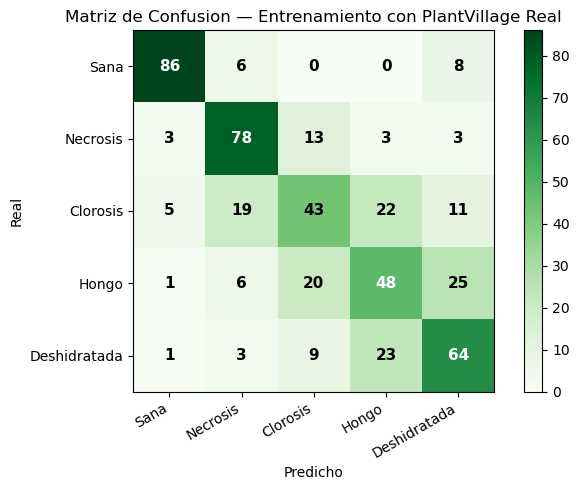


Modelo guardado: c:\Users\victus\Documents\Procesamiento digital\Proyecto\modelo_plantas.pkl
La Celda 6 (sistema en vivo) cargara este modelo automaticamente.


In [7]:
def extraer_features_imagen(ruta_img):
    """
    Lee una imagen de disco, la redimensiona a 320x240 y extrae el vector
    [pct_necrosis, pct_clorosis, pct_hongo, pct_hoja] via segmentar_frame().
    Retorna None si la imagen no se pudo leer.
    """
    frame = cv2.imread(ruta_img)
    if frame is None:
        return None
    frame = cv2.resize(frame, (320, 240))
    r = segmentar_frame(frame)
    return [r['pct_necrosis'], r['pct_clorosis'], r['pct_hongo'], r['pct_hoja']]


def entrenar_con_imagenes_reales(ruta_dataset=RUTA_DATASET_PROCESADO, model_path=MODEL_PATH):
    """
    Recorre dataset_procesado/, extrae el vector de caracteristicas de cada imagen
    mediante segmentar_frame() y entrena un RandomForestClassifier con datos reales.

    Requiere que Celda 4 (organizar_dataset) y Celda 5 (segmentar_frame)
    hayan sido ejecutadas previamente.
    """
    if not os.path.exists(ruta_dataset):
        print(f"ERROR: No se encontro '{ruta_dataset}'.")
        print("Solucion: ejecuta primero la Celda 4 (organizar_dataset).")
        return None

    clases_idx = {'sana': 0, 'necrosis': 1, 'clorosis': 2, 'hongo': 3, 'deshidratada': 4}
    exts = ('.jpg', '.jpeg', '.png')
    X, y, errores = [], [], 0

    print("Extrayendo caracteristicas de las imagenes reales de PlantVillage...")
    print("(Puede tardar 2-5 minutos con 500 imagenes por clase)\n")

    for nombre_clase, idx in clases_idx.items():
        ruta_clase = os.path.join(ruta_dataset, nombre_clase)
        if not os.path.isdir(ruta_clase):
            print(f"  AVISO: carpeta no encontrada — {ruta_clase}")
            continue
        imagenes = [f for f in os.listdir(ruta_clase) if f.lower().endswith(exts)]
        ok = 0
        for img in imagenes:
            features = extraer_features_imagen(os.path.join(ruta_clase, img))
            if features is not None:
                X.append(features)
                y.append(idx)
                ok += 1
            else:
                errores += 1
        print(f"  {nombre_clase:<15s}: {ok} vectores extraidos  ({len(imagenes)} imagenes leidas)")

    if len(X) == 0:
        print("ERROR: No se extrajeron muestras. Verifica que dataset_procesado/ tenga imagenes.")
        return None

    print(f"\nTotal: {len(X)} muestras  |  Errores de lectura: {errores}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Entrenamiento: {len(X_train)}  |  Prueba: {len(X_test)}")

    print("\nEntrenando RandomForestClassifier (100 arboles, datos reales)...")
    modelo_real = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    modelo_real.fit(X_train, y_train)

    precision = modelo_real.score(X_test, y_test)
    print(f"\nPrecision en datos de prueba: {precision:.2%}")

    nombres_clases = [CLASES[i] for i in range(5)]
    print("\nReporte de clasificacion:")
    print(classification_report(y_test, modelo_real.predict(X_test), target_names=nombres_clases))

    cm = confusion_matrix(y_test, modelo_real.predict(X_test))
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(cm, cmap='Greens')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(nombres_clases, rotation=30, ha='right')
    ax.set_yticklabels(nombres_clases)
    plt.colorbar(im, ax=ax)
    for i in range(5):
        for j in range(5):
            tc = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color=tc, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title('Matriz de Confusion — Entrenamiento con PlantVillage Real')
    plt.tight_layout(); plt.show()

    joblib.dump(modelo_real, model_path)
    print(f"\nModelo guardado: {os.path.abspath(model_path)}")
    print("La Celda 6 (sistema en vivo) cargara este modelo automaticamente.")
    return modelo_real


# Entrenar con imagenes reales
# Requiere: Celda 4 ejecutada (dataset_procesado/ existe)
#           Celda 5 ejecutada (segmentar_frame definida)
modelo = entrenar_con_imagenes_reales()


In [9]:
def dibujar_hud(frame, estado, confianza, resultado):
    """Dibuja el panel de diagnostico sobre el frame."""
    h_px, w_px = frame.shape[:2]
    nombre = CLASES[estado]
    color  = COLORES[estado]

    # Panel semitransparente superior (140px de alto)
    panel = frame.copy()
    cv2.rectangle(panel, (0, 0), (w_px, 140), (10, 10, 10), -1)
    cv2.addWeighted(panel, 0.55, frame, 0.45, 0, frame)

    # Linea 1: diagnostico principal
    cv2.putText(frame, f"Estado: {nombre}  ({confianza:.0f}% confianza)",
                (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.80, color, 2, cv2.LINE_AA)

    # Linea 2: porcentajes de dano
    cv2.putText(frame,
                f"Necrosis: {resultado['pct_necrosis']:.1f}%   "
                f"Clorosis: {resultado['pct_clorosis']:.1f}%   "
                f"Hongo: {resultado['pct_hongo']:.1f}%",
                (10, 62), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (220, 220, 220), 1, cv2.LINE_AA)

    # Linea 3: cobertura de hoja
    cv2.putText(frame,
                f"Cobertura de hoja: {resultado['pct_hoja']:.1f}% del encuadre",
                (10, 88), cv2.FONT_HERSHEY_SIMPLEX, 0.52, (160, 240, 160), 1, cv2.LINE_AA)

    # Linea 4: alerta segun estado
    if estado == 4 or resultado['pct_hoja'] < 8.0:
        cv2.putText(frame, "! NECESITA AGUA !",
                    (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.78, (50, 100, 255), 2, cv2.LINE_AA)
    elif estado in (1, 2, 3):
        pct_max = max(resultado['pct_necrosis'], resultado['pct_clorosis'], resultado['pct_hongo'])
        cv2.putText(frame, f"Tratamiento recomendado  ({pct_max:.1f}% area afectada)",
                    (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.60, (0, 200, 255), 2, cv2.LINE_AA)
    else:
        cv2.putText(frame, "Planta saludable",
                    (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.68, (0, 255, 120), 2, cv2.LINE_AA)

    # Instruccion de salida
    cv2.putText(frame, "q = salir",
                (w_px - 95, h_px - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (140, 140, 140), 1)
    return frame


def ejecutar_sistema(indice_camara=0, model_path=MODEL_PATH):
    """
    Bucle principal del sistema de monitoreo en tiempo real.

    Parametros:
        indice_camara : int  camara integrada=0, USB externa=1
        model_path    : str  ruta al modelo .pkl entrenado

    Uso:
        ejecutar_sistema()
        ejecutar_sistema(indice_camara=1)
    """
    if not os.path.exists(model_path):
        print(f"ERROR: No se encontro el modelo en '{model_path}'.")
        print("Solucion: ejecuta primero la Celda 4 (entrenamiento).")
        return

    modelo_local = joblib.load(model_path)

    cap = cv2.VideoCapture(indice_camara)
    if not cap.isOpened():
        print(f"ERROR: No se pudo abrir la camara con indice {indice_camara}.")
        print(f"Prueba con: ejecutar_sistema(indice_camara=1)")
        return

    ancho = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    alto  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Sistema iniciado — Camara {indice_camara} ({ancho}x{alto})")
    print("Apunta la camara hacia una hoja. Presiona 'q' en la ventana para salir.")

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                print("Advertencia: no se pudo leer el frame. Reintentando...")
                continue

            resultado    = segmentar_frame(frame)
            estado, conf = predecir_estado(resultado, modelo_local)
            frame_final  = dibujar_hud(resultado['anotado'], estado, conf, resultado)

            cv2.imshow('Sistema Monitoreo Plantas - PDI Univalle', frame_final)

            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Sistema detenido por el usuario.")
                break
    finally:
        cap.release()
        cv2.destroyAllWindows()
        print("Camara y ventanas liberadas correctamente.")


# Ejecutar el sistema
# Cambia indice_camara=1 si la camara integrada no funciona
ejecutar_sistema(indice_camara=0)


Sistema iniciado — Camara 0 (640x480)
Apunta la camara hacia una hoja. Presiona 'q' en la ventana para salir.
Sistema detenido por el usuario.
Camara y ventanas liberadas correctamente.


## Celda 7 — Consejos y solución de errores comunes

| Problema | Causa probable | Solución |
|---|---|---|
| `No module named 'cv2'` | Entorno incorrecto | Verifica que el kernel sea **pdi** en la esquina superior derecha de VS Code |
| La ventana de video no aparece | Jupyter remoto o display | Ejecuta desde VS Code local (no SSH); prueba `cv2.imshow` desde terminal |
| Cámara no se abre (índice 0) | Otro programa la usa | Cierra otras apps; prueba `ejecutar_sistema(indice_camara=1)` |
| Kernel colgado / no responde | Bucle sin salida | **Kernel → Interrupt**; si persiste, **Kernel → Restart** |
| `ImportError` con Python 3.14 | Versión muy nueva | Crea entorno estable: `conda create -n pdi311 python=3.11` |
| Ventana se cierra sola | Foco perdido en `waitKey` | Haz clic dentro de la ventana OpenCV antes de presionar `q` |
| `modelo_plantas.pkl` no encontrado | No se ejecutó Celda 4 | Ejecuta la Celda 4 primero para entrenar y guardar el modelo |
| Frame siempre negro | Frames iniciales descartados insuficientes | Aumenta el `range(30)` a `range(60)` en `probar_camara()` |

### Cómo liberar la cámara si el notebook se cuelga
```python
# Ejecuta esta celda de emergencia si la cámara queda bloqueada:
import cv2
cap = cv2.VideoCapture(0)
cap.release()
cv2.destroyAllWindows()
print("Cámara liberada.")
```

### Ajuste de rangos HSV
Los rangos HSV dependen de la iluminación. Si la detección no funciona bien, usa este snippet para explorar los valores con tu imagen:
```python
# Diagnóstico HSV — muestra los valores del píxel central
import cv2, numpy as np
cap = cv2.VideoCapture(0)
ret, frame = cap.read()
cap.release()
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
h, w = frame.shape[:2]
print("HSV en el centro del frame:", hsv[h//2, w//2])
```
